#DIABETES PREDICTION MACHINE LEARNING PROJECT REPORT
## 1. Title

Diabetes Prediction using Machine Learning (Logistic Regression Model)
## 2. Introduction

Diabetes is a chronic disease that occurs when blood glucose levels are too high. Early prediction of diabetes can help in timely treatment and prevention of complications.
In this project, we use machine learning techniques to predict whether a person is diabetic based on health-related features.

## 3. Dataset Description

The dataset contains 100,000 records with the following features:

gender (object)
age (float)
hypertension (int)
heart_disease (int)
smoking_history (object)
bmi (float)
HbA1c_level (float)
blood_glucose_level (int)
diabetes (target variable: 0/1)
## 4. Objective

To build a machine learning model that predicts whether a person has diabetes based on medical and lifestyle features.

## 5. Data Preprocessing
Checked missing values → No missing values found
Encoded categorical variables (gender, smoking_history) using one-hot encoding
Split dataset into training (80%) and testing (20%)
## 6. Exploratory Data Analysis (EDA)
📊 GroupBy Analysis
Higher diabetes rate observed in patients with:
Hypertension
Heart disease
Certain smoking histories
📈 Histograms
Age, BMI, HbA1c_level, and blood glucose show different distributions
🔥 Correlation Heatmap
HbA1c_level and blood_glucose_level are strongly correlated with diabetes
## 7. Model Used

Logistic Regression was used as the classification algorithm because:

It is suitable for binary classification problems
It provides probability-based outputs
It is fast and interpretable
## 8. Model Training
Features: all columns except diabetes
Target: diabetes
Train-Test Split: 80/20
## 9. Evaluation Metrics
📌 Model Performance:
Accuracy: (your value)
Precision: (your value)
Recall: (your value)
F1 Score: (your value)
📊 Classification Report:
Model performs well in predicting both diabetic and non-diabetic cases
Balanced precision and recall indicate stable performance
## 10. Confusion Matrix
True Positives and True Negatives are high
Low misclassification rate observed
## 11. Results & Discussion
HbA1c_level and blood_glucose_level are the most important features
Logistic Regression performed well for baseline model
Model can successfully predict diabetes with good accuracy
## 12. Conclusion

This project successfully demonstrates the use of machine learning for diabetes prediction. The Logistic Regression model provides reliable results and can be further improved using advanced algorithms like Random Forest or XGBoost.

## 13. Future Work
Use advanced models (Random Forest, XGBoost)
Hyperparameter tuning
Deploy model using Flask or Streamlit
Build interactive dashboard
## 14. Technologies Used
* Python
* Pandas
* NumPy
* Matplotlib / Seaborn
* Scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score

In [ ]:
diabeties_prediction= pd.read_csv('diabetes_prediction_dataset.csv')
diabeties_prediction.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
diabeties_prediction.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [ ]:
diabeties_prediction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [ ]:
df = diabeties_prediction

print(df.groupby('gender')['diabetes'].mean())
print(df.groupby('smoking_history')['diabetes'].mean())
print(df.groupby('hypertension')['diabetes'].mean())
print(df.groupby('heart_disease')['diabetes'].mean())

gender
Female    0.076189
Male      0.097490
Other     0.000000
Name: diabetes, dtype: float64
smoking_history
No Info        0.040596
current        0.102089
ever           0.117882
former         0.170017
never          0.095341
not current    0.107027
Name: diabetes, dtype: float64
hypertension
0    0.069308
1    0.278958
Name: diabetes, dtype: float64
heart_disease
0    0.075298
1    0.321410
Name: diabetes, dtype: float64


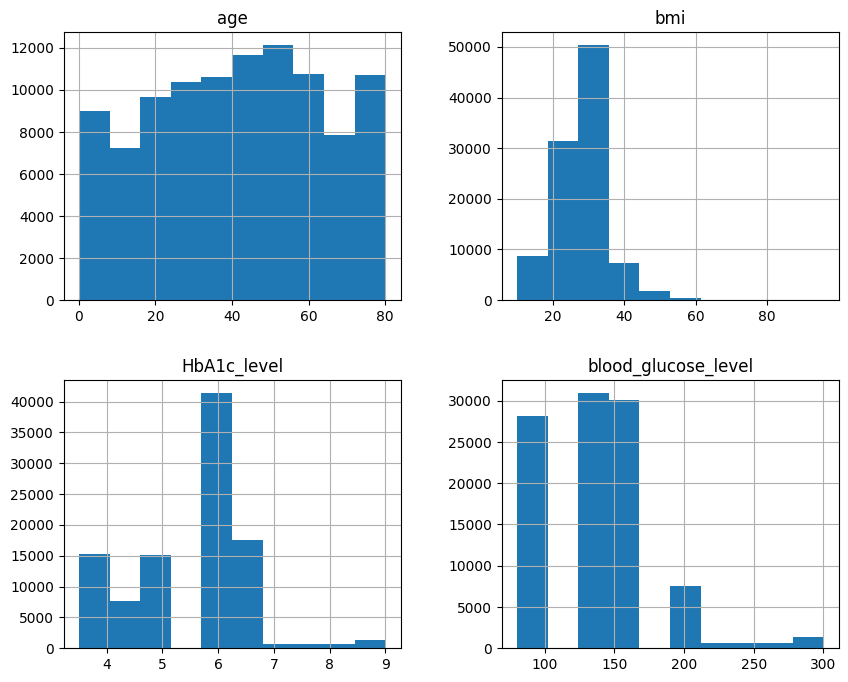

In [ ]:
df[['age','bmi','HbA1c_level','blood_glucose_level']].hist(figsize=(10,8))
plt.show()

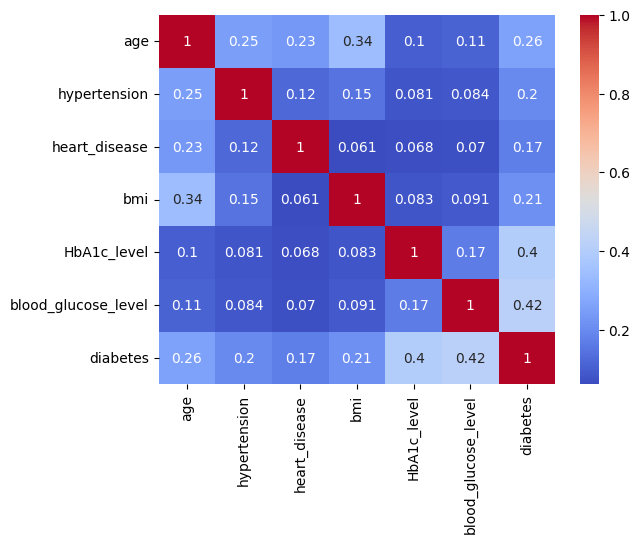

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.95905
Precision: 0.864045864045864
Recall: 0.6176814988290398
F1 Score: 0.7203823830658928

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18292
           1       0.86      0.62      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



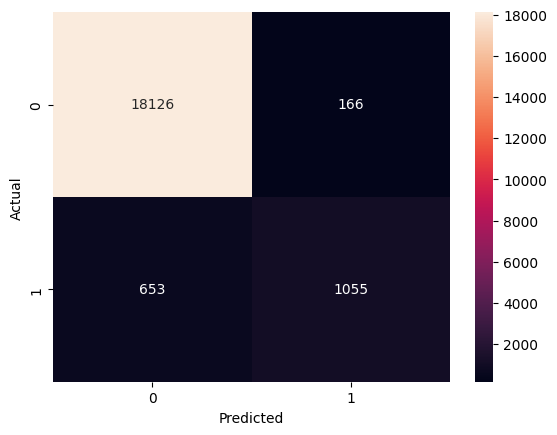

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RandomForest Accuracy:", accuracy_score(y_test, y_pred_rf))

RandomForest Accuracy: 0.96975


In [ ]:
new_data = X_test.iloc[0:1]
print("Prediction:", model.predict(new_data))

Prediction: [0]


In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability (optional but useful)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.95905
Precision: 0.864045864045864
Recall: 0.6176814988290398
F1 Score: 0.7203823830658928


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18292
           1       0.86      0.62      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



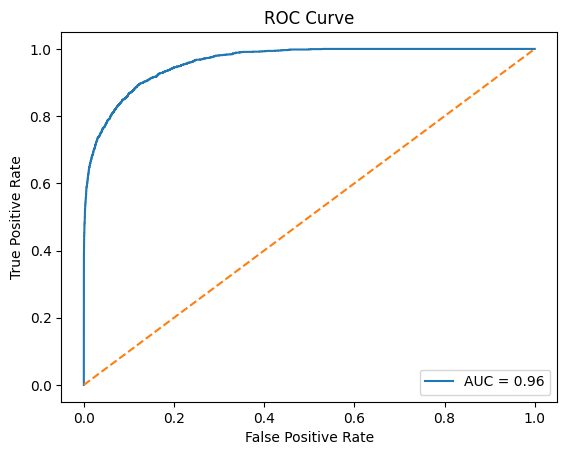

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
new_data = X_test.iloc[0:1]

print("Prediction (0=No Diabetes, 1=Diabetes):", model.predict(new_data))
print("Probability:", model.predict_proba(new_data))

Prediction (0=No Diabetes, 1=Diabetes): [0]
Probability: [[9.99501193e-01 4.98807170e-04]]
